In [1]:
# ============================================================
# 0. Setup and Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
print("Libraries loaded.")


Libraries loaded.


In [2]:
# ============================================================
# 1. Load Dataset and Basic Feature Construction
# ============================================================

# WARNING: replace this path with the correct one on your system
df = pd.read_csv("/home/lorenzods/progetto_mastercard/dataset/creditcard_enhanced_UAE_FINAL.csv")

# Cost of fraud = 4.19 * Amount (AED)
df["cost_if_fraud"] = 4.19 * df["Amount"]

# Flag high-value transactions >= 50K AED
df["flag_over_50k"] = (df["Amount"] >= 50000).astype(int)

print(f"Dataset shape: {df.shape}")
print(f"Fraud rate:    {df['Class'].mean()*100:.4f}%")
print(f"Total frauds:  {df['Class'].sum()}")
print("Head of dataset:")
print(df.head(3))


Dataset shape: (284807, 41)
Fraud rate:    0.1727%
Total frauds:  492
Head of dataset:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   

         V8        V9  ...  transaction_type  Time_days      geo_area  \
0  0.098698  0.363787  ...               B2C   0.000000  Dubai_Marina   
1  0.085102 -0.255425  ...               B2C   0.000000       Sharjah   
2  0.247676 -1.514654  ...               B2C   0.000012        Al_Ain   

   customer_id  customer_type  age  is_3DS  is_tokenized  cost_if_fraud  \
0       123304          EXPAT   37       0             1       626.9078   
1       479353          EXPAT   37       1             1        11.2711   
2       512369          EXPAT   30       1             0      1586.585

In [3]:
# ============================================================
# 2. Train / Validation / Test Split (no leakage)
#    60% train | 20% validation | 20% test
# ============================================================

df_main = df.copy()

target_column = "Class"
y_full = df_main[target_column]

# Columns to exclude from features
drop_cols = ["Class", "cost_if_fraud", "flag_over_50k", "customer_id", "Time"]
X_full = df_main.drop(columns=[c for c in drop_cols if c in df_main.columns])

# First split: hold out test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_full, y_full, test_size=0.20, stratify=y_full, random_state=42
)

# Second split: train (60%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

idx_train = X_train.index
idx_val   = X_val.index
idx_test  = X_test.index

print(f"Train:      {len(X_train):>7}  |  Frauds: {y_train.sum()}")
print(f"Validation: {len(X_val):>7}  |  Frauds: {y_val.sum()}")
print(f"Test:       {len(X_test):>7}  |  Frauds: {y_test.sum()}")


Train:       170883  |  Frauds: 295
Validation:   56962  |  Frauds: 99
Test:         56962  |  Frauds: 98


In [4]:
# ============================================================
# 3. Encoding and Feature Engineering
#    Single encode_binary function — no duplication,
#    no risk of double-encoding.
# ============================================================

binary_mapping = {
    "transaction_type": {"B2C": 0, "B2B": 1},
    "customer_type":    {"EXPAT": 0, "LOCAL": 1},
}

def encode_binary(X, mappings):
    """Apply binary label mappings. Operates on a copy."""
    X = X.copy()
    for col, mapping in mappings.items():
        if col in X.columns:
            X[col] = X[col].map(mapping)
    return X

binary_cat_cols = [c for c in ["transaction_type", "customer_type"] if c in X_train.columns]
ohe_cat_cols    = [c for c in ["geo_area"]                           if c in X_train.columns]

X_train = encode_binary(X_train, binary_mapping)
X_val   = encode_binary(X_val,   binary_mapping)
X_test  = encode_binary(X_test,  binary_mapping)

if ohe_cat_cols:
    X_train = pd.get_dummies(X_train, columns=ohe_cat_cols)
    train_columns = X_train.columns
    X_val  = pd.get_dummies(X_val,  columns=ohe_cat_cols).reindex(columns=train_columns, fill_value=0)
    X_test = pd.get_dummies(X_test, columns=ohe_cat_cols).reindex(columns=train_columns, fill_value=0)
else:
    train_columns = X_train.columns

print(f"Feature matrix shape (train): {X_train.shape}")
print(f"First 8 columns: {list(train_columns[:8])} ...")


Feature matrix shape (train): (170883, 41)
First 8 columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8'] ...


In [5]:
# ============================================================
# 4. Scaling — fit ONLY on train, transform val and test
# ============================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done (fitted on train only).")


Scaling done (fitted on train only).


In [6]:
# ============================================================
# 5. XGBoost — grid search on scale_pos_weight
#
#    FIX (vs v2): selection criterion is now MINIMUM COST
#    on the validation set after threshold tuning — not
#    maximum fraud-probability median, which always selected
#    the highest spw and made the grid search pointless.
# ============================================================

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
raw_ratio = n_neg / n_pos

print(f"Class distribution in train set:")
print(f"  Negative (legit): {n_neg}")
print(f"  Positive (fraud): {n_pos}")
print(f"  Raw class ratio:  {raw_ratio:.2f}")
print()

costs_val = df_main.loc[idx_val, "cost_if_fraud"].values

spw_candidates = [
    raw_ratio,
    raw_ratio / 2,
    raw_ratio / 4,
    raw_ratio / 8,
    raw_ratio / 16,
    10.0
]

quick_thresholds = np.concatenate([
    np.linspace(0.01, 0.50, 20),
    np.linspace(0.50, 0.90, 20),
    np.linspace(0.90, 0.999, 60)
])

results_spw = {}
print(f"  {'SPW':>8} | {'Fraud median':>13} | {'Best thr':>9} | {'Min cost (AED)':>16} | {'FP':>5} | {'FN':>5}")
print("  " + "-" * 72)

for spw in spw_candidates:
    m = XGBClassifier(
        learning_rate=0.1, max_depth=3,
        scale_pos_weight=spw, subsample=1.0,
        eval_metric="logloss", random_state=42
    )
    m.fit(X_train_scaled, y_train)
    probs_val = m.predict_proba(X_val_scaled)[:, 1]

    best_t, best_c, best_fp_c, best_fn_c = 0.5, float("inf"), 0, 0
    for t in quick_thresholds:
        y_tmp = (probs_val >= t).astype(int)
        fp_m  = (y_tmp == 1) & (y_val.values == 0)
        fn_m  = (y_tmp == 0) & (y_val.values == 1)
        cost_t = fp_m.sum() * 50 + costs_val[fn_m].sum()
        if cost_t < best_c:
            best_c, best_t = cost_t, t
            best_fp_c, best_fn_c = fp_m.sum(), fn_m.sum()

    fraud_med = np.median(probs_val[y_val.values == 1])
    results_spw[spw] = {
        "model": m, "probs_val": probs_val,
        "best_thr": best_t, "min_cost": best_c,
        "fraud_med": fraud_med, "fp": best_fp_c, "fn": best_fn_c,
    }
    print(f"  {spw:>8.1f} | {fraud_med:>13.4f} | {best_t:>9.4f} | {best_c:>16,.2f} | {best_fp_c:>5} | {best_fn_c:>5}")

# FIX: select by minimum validation cost
best_spw    = min(results_spw, key=lambda s: results_spw[s]["min_cost"])
model       = results_spw[best_spw]["model"]
y_val_prob  = results_spw[best_spw]["probs_val"]
y_test_prob = model.predict_proba(X_test_scaled)[:, 1]

print(f"Best scale_pos_weight: {best_spw:.2f}")
print(f"  Fraud median on val: {results_spw[best_spw]['fraud_med']:.4f}")
print(f"  Preliminary min cost: {results_spw[best_spw]['min_cost']:,.2f} AED")


Class distribution in train set:
  Negative (legit): 170588
  Positive (fraud): 295
  Raw class ratio:  578.26

       SPW |  Fraud median |  Best thr |   Min cost (AED) |    FP |    FN
  ------------------------------------------------------------------------
     578.3 |        0.9988 |    0.9906 |        70,631.81 |    10 |    27
     289.1 |        0.9978 |    0.9856 |        70,581.81 |     9 |    27
     144.6 |        0.9967 |    0.2679 |        64,599.42 |   269 |    16
      72.3 |        0.9960 |    0.1647 |        63,450.62 |   247 |    15
      36.1 |        0.9934 |    0.9034 |        70,569.70 |    10 |    24
      10.0 |        0.9804 |    0.8579 |        70,424.44 |     6 |    24
Best scale_pos_weight: 72.28
  Fraud median on val: 0.9960
  Preliminary min cost: 63,450.62 AED


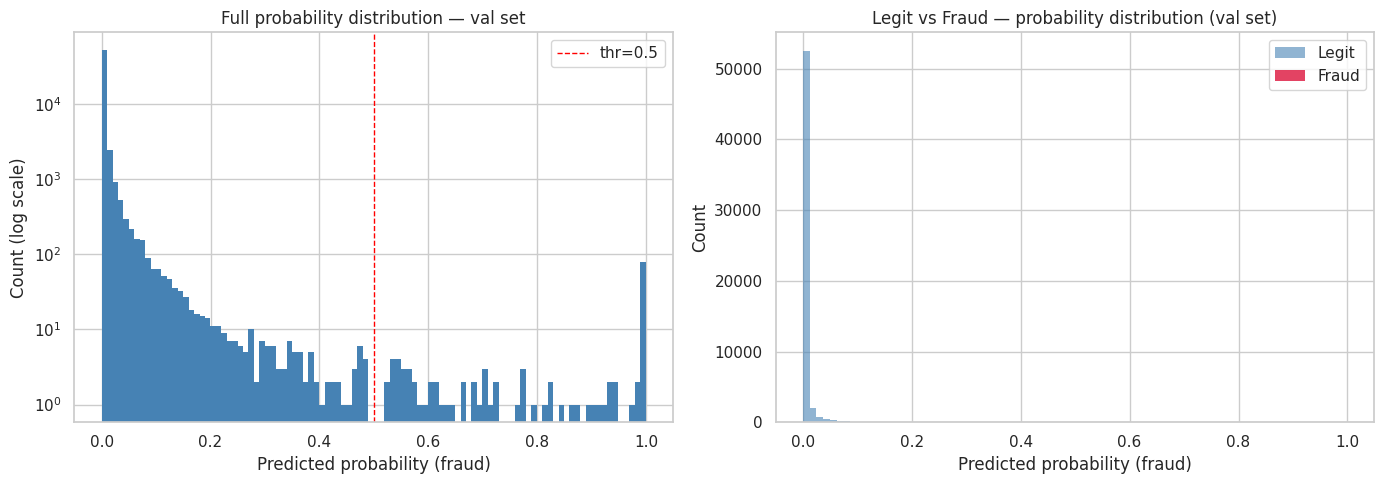

=== Fraud probability statistics (val set) ===
  Min:          0.0010
  Max:          0.9988
  Median:       0.9960
  Mean:         0.8146
  % above 0.50: 82.8%
  % above 0.90: 75.8%
  % above 0.99: 69.7%
=== Legit probability statistics (val set) ===
  % above 0.50: 0.098%
  % above 0.90: 0.023%
  % above 0.99: 0.016%


In [7]:
# ============================================================
# 5b. Diagnostics: predicted probability distribution
# ============================================================

mask_fraud_val = (y_val.values == 1)
mask_legit_val = (y_val.values == 0)
fraud_probs    = y_val_prob[mask_fraud_val]
legit_probs    = y_val_prob[mask_legit_val]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_val_prob, bins=100, color="steelblue", edgecolor="none")
axes[0].set_yscale("log")
axes[0].set_xlabel("Predicted probability (fraud)")
axes[0].set_ylabel("Count (log scale)")
axes[0].set_title("Full probability distribution — val set")
axes[0].axvline(0.5, color="red", linestyle="--", linewidth=1, label="thr=0.5")
axes[0].legend()

axes[1].hist(legit_probs, bins=80, alpha=0.6, color="steelblue", label="Legit", edgecolor="none")
axes[1].hist(fraud_probs, bins=80, alpha=0.8, color="crimson",   label="Fraud", edgecolor="none")
axes[1].set_xlabel("Predicted probability (fraud)")
axes[1].set_ylabel("Count")
axes[1].set_title("Legit vs Fraud — probability distribution (val set)")
axes[1].legend()

plt.tight_layout()
plt.savefig("prob_distribution_val.png", dpi=150, bbox_inches="tight")
plt.show()

print("=== Fraud probability statistics (val set) ===")
print(f"  Min:          {fraud_probs.min():.4f}")
print(f"  Max:          {fraud_probs.max():.4f}")
print(f"  Median:       {np.median(fraud_probs):.4f}")
print(f"  Mean:         {fraud_probs.mean():.4f}")
print(f"  % above 0.50: {(fraud_probs > 0.50).mean()*100:.1f}%")
print(f"  % above 0.90: {(fraud_probs > 0.90).mean()*100:.1f}%")
print(f"  % above 0.99: {(fraud_probs > 0.99).mean()*100:.1f}%")
print("=== Legit probability statistics (val set) ===")
print(f"  % above 0.50: {(legit_probs > 0.50).mean()*100:.3f}%")
print(f"  % above 0.90: {(legit_probs > 0.90).mean()*100:.3f}%")
print(f"  % above 0.99: {(legit_probs > 0.99).mean()*100:.3f}%")


Best threshold (validation): 0.1790
Minimum cost (validation):   62,400.62 AED


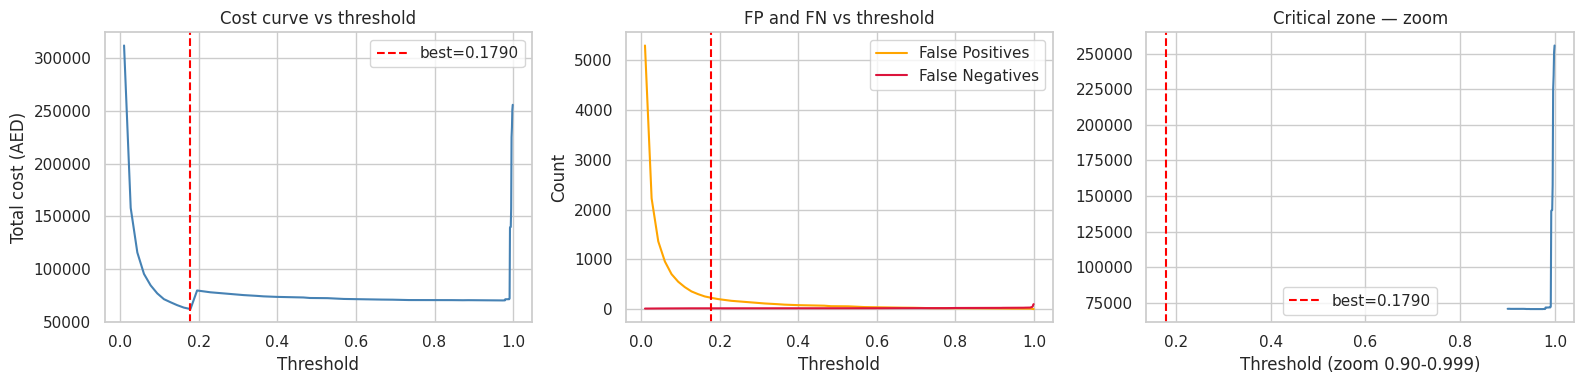

In [8]:
# ============================================================
# 6. Cost-based Threshold Tuning — adaptive range
#
#    FIX (vs v2): single tuning cell. The old linspace(0.01,
#    0.99) version has been removed. Dense sampling in the
#    0.90-0.999 zone where fraud probabilities actually live.
# ============================================================

costs_val = df_main.loc[idx_val, "cost_if_fraud"].values

thresholds = np.concatenate([
    np.linspace(0.01, 0.50, 30),
    np.linspace(0.50, 0.90, 30),
    np.linspace(0.90, 0.999, 100)
])

best_thr = 0.5
min_cost = float("inf")
cost_curve = []

for thr in thresholds:
    y_pred_tmp = (y_val_prob >= thr).astype(int)
    fp_mask    = (y_pred_tmp == 1) & (y_val.values == 0)
    fn_mask    = (y_pred_tmp == 0) & (y_val.values == 1)
    cost_fp    = fp_mask.sum() * 50
    cost_fn    = costs_val[fn_mask].sum()
    total_cost = cost_fp + cost_fn
    cost_curve.append((thr, total_cost, fp_mask.sum(), fn_mask.sum()))
    if total_cost < min_cost:
        min_cost = total_cost
        best_thr = thr

curve_df = pd.DataFrame(cost_curve, columns=["thr", "cost", "fp", "fn"])

print(f"Best threshold (validation): {best_thr:.4f}")
print(f"Minimum cost (validation):   {min_cost:,.2f} AED")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(curve_df["thr"], curve_df["cost"], color="steelblue")
axes[0].axvline(best_thr, color="red", linestyle="--", label=f"best={best_thr:.4f}")
axes[0].set_xlabel("Threshold"); axes[0].set_ylabel("Total cost (AED)")
axes[0].set_title("Cost curve vs threshold"); axes[0].legend()

axes[1].plot(curve_df["thr"], curve_df["fp"], color="orange", label="False Positives")
axes[1].plot(curve_df["thr"], curve_df["fn"], color="crimson", label="False Negatives")
axes[1].axvline(best_thr, color="red", linestyle="--")
axes[1].set_xlabel("Threshold"); axes[1].set_ylabel("Count")
axes[1].set_title("FP and FN vs threshold"); axes[1].legend()

zone = curve_df[curve_df["thr"] >= 0.90]
axes[2].plot(zone["thr"], zone["cost"], color="steelblue")
axes[2].axvline(best_thr, color="red", linestyle="--", label=f"best={best_thr:.4f}")
axes[2].set_xlabel("Threshold (zoom 0.90-0.999)")
axes[2].set_title("Critical zone — zoom"); axes[2].legend()

plt.tight_layout()
plt.savefig("threshold_tuning_curve.png", dpi=150, bbox_inches="tight")
plt.show()


In [9]:
# ============================================================
# 6b. Threshold Robustness — sensitivity analysis
#     Dynamic window centered on best_thr
# ============================================================

window    = 0.10  # ±10% around best threshold
thr_lo    = max(0.0,  best_thr - window)
thr_hi    = min(1.0,  best_thr + window)

zone_fine = curve_df[
    (curve_df["thr"] >= thr_lo) &
    (curve_df["thr"] <= thr_hi)
].copy()
zone_fine["delta_cost_pct"] = (zone_fine["cost"] - min_cost) / min_cost * 100

print(f"=== Sensitivity around best_thr={best_thr:.4f} "
      f"(window [{thr_lo:.4f} — {thr_hi:.4f}]) ===")
print(f"  {'Threshold':>10} | {'Cost (AED)':>14} | {'Delta vs min':>13} | {'FP':>5} | {'FN':>5}")
print("  " + "-" * 62)

for _, row in zone_fine.iterrows():
    marker = "  <-- BEST" if abs(row["thr"] - best_thr) < 1e-6 else ""
    print(
        f"  {row['thr']:>10.4f} | {row['cost']:>14,.0f} | "
        f"{row['delta_cost_pct']:>+12.1f}% | "
        f"{int(row['fp']):>5} | {int(row['fn']):>5}{marker}"
    )

# Robust zone: thresholds within +5% of minimum cost
acceptable = zone_fine[zone_fine["delta_cost_pct"] <= 5.0]

if acceptable.empty:
    print("\n⚠️  No threshold qualifies for the robust zone — using best_thr as operational.")
    thr_low  = best_thr
    thr_high = best_thr
else:
    thr_low  = float(acceptable["thr"].min())
    thr_high = float(acceptable["thr"].max())

print(f"\nRobust zone (cost <= +5% of minimum): [{thr_low:.4f} — {thr_high:.4f}]")
print(f"Width: {(thr_high - thr_low):.4f}")

# Operational threshold: lowest value in the robust zone
best_thr_operational = thr_low

idx_pure = (curve_df["thr"] - best_thr).abs().idxmin()
idx_oper = (curve_df["thr"] - best_thr_operational).abs().idxmin()
row_pure = curve_df.loc[idx_pure]
row_oper = curve_df.loc[idx_oper]

print(f"\n--- Threshold comparison (val set) ---")
print(
    f"  Tuning optimum:    thr={float(row_pure['thr']):.4f}  "
    f"FP={int(row_pure['fp']):>4}  FN={int(row_pure['fn']):>3}  "
    f"Cost={float(row_pure['cost']):>10,.0f} AED"
)
print(
    f"  Operational best:  thr={float(row_oper['thr']):.4f}  "
    f"FP={int(row_oper['fp']):>4}  FN={int(row_oper['fn']):>3}  "
    f"Cost={float(row_oper['cost']):>10,.0f} AED"
)

delta_frauds = int(row_pure["fn"]) - int(row_oper["fn"])
delta_cost   = float(row_oper["cost"]) - float(row_pure["cost"])
print(f"\n  Extra frauds caught by operational threshold: +{delta_frauds}")
print(
    f"  Extra cost vs pure optimum:                   +{delta_cost:,.0f} AED  "
    f"({delta_cost / float(row_pure['cost']) * 100:+.2f}%)"
)

# Propagate operational threshold to all downstream sections
best_thr = best_thr_operational
print(f"\nActive threshold set to: {best_thr:.4f}")

=== Sensitivity around best_thr=0.1790 (window [0.0790 — 0.2790]) ===
   Threshold |     Cost (AED) |  Delta vs min |    FP |    FN
  --------------------------------------------------------------
      0.0945 |         77,244 |        +23.8% |   550 |    14
      0.1114 |         71,794 |        +15.1% |   441 |    14
      0.1283 |         68,851 |        +10.3% |   355 |    15
      0.1452 |         66,101 |         +5.9% |   300 |    15
      0.1621 |         63,801 |         +2.2% |   254 |    15
      0.1790 |         62,401 |         +0.0% |   226 |    15  <-- BEST
      0.1959 |         79,980 |        +28.2% |   201 |    16
      0.2128 |         79,129 |        +26.8% |   183 |    17
      0.2297 |         78,279 |        +25.4% |   166 |    17
      0.2466 |         77,729 |        +24.6% |   155 |    17
      0.2634 |         77,179 |        +23.7% |   144 |    17

Robust zone (cost <= +5% of minimum): [0.1621 — 0.1790]
Width: 0.0169

--- Threshold comparison (val set) ---


--- Confusion Matrix (XGBoost, test set) ---
[[56589   275]
 [   11    87]]
  TP (caught frauds): 87
  FN (missed frauds): 11
  FP (false alarms):  275
  TN (correct legit): 56589
--- Classification Report ---
              precision    recall  f1-score   support

           0     0.9998    0.9952    0.9975     56864
           1     0.2403    0.8878    0.3783        98

    accuracy                         0.9950     56962
   macro avg     0.6201    0.9415    0.6879     56962
weighted avg     0.9985    0.9950    0.9964     56962



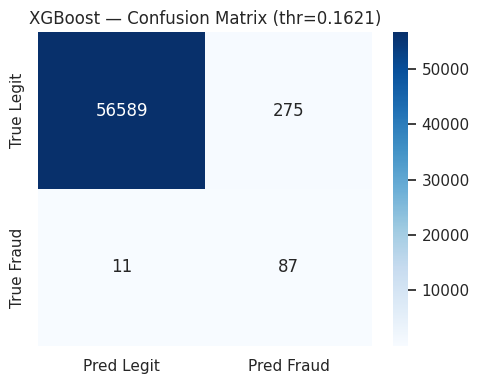

In [10]:
# ============================================================
# 7. XGBoost Evaluation on Test Set
# ============================================================

y_pred_test = (y_test_prob >= best_thr).astype(int)

cm_test = confusion_matrix(y_test, y_pred_test)
print("--- Confusion Matrix (XGBoost, test set) ---")
print(cm_test)
tn_x, fp_t, fn_t, tp_t = cm_test.ravel()
print(f"  TP (caught frauds): {tp_t}")
print(f"  FN (missed frauds): {fn_t}")
print(f"  FP (false alarms):  {fp_t}")
print(f"  TN (correct legit): {tn_x}")
print("--- Classification Report ---")
print(classification_report(y_test, y_pred_test, digits=4))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Legit", "Pred Fraud"],
            yticklabels=["True Legit", "True Fraud"], ax=ax)
ax.set_title(f"XGBoost — Confusion Matrix (thr={best_thr:.4f})")
plt.tight_layout()
plt.savefig("cm_xgboost.png", dpi=150, bbox_inches="tight")
plt.show()


In [11]:
# ============================================================
# 8. Business Impact Simulation
#    — test set only (no leakage)
#    — separate cost_manual_unit for high-value reviews
#    — FIX: rates printed in scientific notation (no more 0.00)
# ============================================================

def simulate_business_impact(
        df_eval, model, best_thr, scaler, train_columns,
        annual_volume=12_000_000, cost_fp_unit=50, cost_manual_unit=200
    ):
    df_seg = df_eval[df_eval["Amount"] < 50000].copy()
    y_seg  = df_seg["Class"]
    X_seg  = df_seg.drop(
        columns=["Class", "customer_id", "Time", "cost_if_fraud",
                 "flag_over_50k", "model_score", "flag_xgb", "flag_ensemble"],
        errors="ignore"
    )
    X_seg = encode_binary(X_seg, binary_mapping)
    if ohe_cat_cols:
        X_seg = pd.get_dummies(X_seg, columns=ohe_cat_cols)
    X_seg = X_seg.reindex(columns=train_columns, fill_value=0)
    X_seg_scaled = scaler.transform(X_seg)
    cost_seg = df_seg["cost_if_fraud"].values

    y_scores = model.predict_proba(X_seg_scaled)[:, 1]
    y_pred   = (y_scores >= best_thr).astype(int)
    fp_mask  = (y_pred == 1) & (y_seg.values == 0)
    fn_mask  = (y_pred == 0) & (y_seg.values == 1)

    cost_fp = fp_mask.sum() * cost_fp_unit
    cost_fn = cost_seg[fn_mask].sum()

    df_high_value     = df_eval[df_eval["Amount"] >= 50000]
    cost_manual_check = len(df_high_value) * cost_manual_unit
    scaling_factor    = annual_volume / len(df_seg)

    annual_cost_fp     = cost_fp           * scaling_factor
    annual_cost_fn     = cost_fn           * scaling_factor
    annual_cost_manual = cost_manual_check * scaling_factor
    total_cost         = annual_cost_fp + annual_cost_fn + annual_cost_manual

    return {
        "Evaluation subset size":           len(df_eval),
        "Main segment (<50K) transactions": len(df_seg),
        "High-value (>=50K) transactions":  len(df_high_value),
        "False positive rate (<50K)":       fp_mask.mean(),
        "False negative rate (<50K)":       fn_mask.mean(),
        "Estimated false negatives (<50K)": int(fn_mask.sum()),
        "Annual FP cost":                   annual_cost_fp,
        "Annual FN cost":                   annual_cost_fn,
        "Manual review cost (>=50K)":       annual_cost_manual,
        "TOTAL estimated annual cost":      total_cost
    }

df_test_subset = df_main.loc[idx_test]
results_sim = simulate_business_impact(
    df_eval=df_test_subset, model=model, best_thr=best_thr,
    scaler=scaler, train_columns=train_columns
)

print("--- Business Impact Simulation (test set only) ---")
for k, v in results_sim.items():
    if isinstance(v, float):
        if 0 < abs(v) < 0.01:
            print(f"  {k}: {v:.4e}")
        else:
            print(f"  {k}: {v:,.2f}")
    else:
        print(f"  {k}: {v}")


--- Business Impact Simulation (test set only) ---
  Evaluation subset size: 56962
  Main segment (<50K) transactions: 56953
  High-value (>=50K) transactions: 9
  False positive rate (<50K): 4.8110e-03
  False negative rate (<50K): 1.9314e-04
  Estimated false negatives (<50K): 11
  Annual FP cost: 2,886,590.70
  Annual FN cost: 1,758,731.82
  Manual review cost (>=50K): 379,260.09
  TOTAL estimated annual cost: 5,024,582.61


In [12]:
# ============================================================
# 9. Unsupervised Anomaly Detection Layer
#    IsolationForest + LOF fitted on train-only legit txns
#    FIX: tighter parameters to reduce the +1369 FP problem
# ============================================================

def prepare_features(X_raw, binary_mapping, ohe_cat_cols, train_columns, scaler):
    """Centralised encoding + scaling — single source of truth."""
    X = encode_binary(X_raw.copy(), binary_mapping)
    if ohe_cat_cols:
        X = pd.get_dummies(X, columns=ohe_cat_cols)
    X = X.reindex(columns=train_columns, fill_value=0)
    return scaler.transform(X)

# 9.0 — Score ALL transactions
X_all_raw    = df_main.drop(
    columns=["Class", "customer_id", "Time", "cost_if_fraud", "flag_over_50k"],
    errors="ignore"
)
X_all_scaled  = prepare_features(X_all_raw, binary_mapping, ohe_cat_cols, train_columns, scaler)
y_scores_all  = model.predict_proba(X_all_scaled)[:, 1]
df_main["model_score"] = y_scores_all

# 9.1 — Keep only transactions XGBoost classified as LEGIT
mask_pred_legit_all = (y_scores_all < best_thr)
df_pred_legit       = df_main[mask_pred_legit_all].copy()

X_legit_raw    = df_pred_legit.drop(
    columns=["Class", "customer_id", "Time", "cost_if_fraud",
             "flag_over_50k", "model_score"],
    errors="ignore"
)
X_legit_scaled = prepare_features(X_legit_raw, binary_mapping, ohe_cat_cols, train_columns, scaler)

train_mask_in_legit = df_pred_legit.index.isin(idx_train)
X_legit_train       = X_legit_scaled[train_mask_in_legit]
print(f"Legit-train transactions used to fit anomaly models: {X_legit_train.shape[0]}")

# 9.2 — Isolation Forest
# FIX: percentile raised from 98.5 to 99.5 — fewer flags
iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
iso_forest.fit(X_legit_train)
anomaly_scores_iso = iso_forest.decision_function(X_legit_scaled)
df_pred_legit["anomaly_score_iforest"] = -anomaly_scores_iso

train_anomaly_scores = df_pred_legit.loc[train_mask_in_legit, "anomaly_score_iforest"]
threshold_iso        = np.percentile(train_anomaly_scores, 99.5)  # was 98.5
df_pred_legit["flag_iforest"] = df_pred_legit["anomaly_score_iforest"] >= threshold_iso
print(f"IsolationForest threshold (99.5p of train): {threshold_iso:.4f}")
print(f"Transactions flagged by IForest:            {df_pred_legit['flag_iforest'].sum()}")

# 9.3 — LOF
# FIX: contamination lowered from 0.01 to 0.001 — 10x fewer flags
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.001,  # was 0.01
    novelty=True
)
lof.fit(X_legit_train)
lof_flags = lof.predict(X_legit_scaled)
df_pred_legit["flag_lof"] = (lof_flags == -1)
print(f"Transactions flagged by LOF:                {df_pred_legit['flag_lof'].sum()}")
print(f"Flagged by at least one (IF OR LOF):        {(df_pred_legit['flag_iforest'] | df_pred_legit['flag_lof']).sum()}")

Legit-train transactions used to fit anomaly models: 169852
IsolationForest threshold (99.5p of train): 0.0243
Transactions flagged by IForest:            1461
Transactions flagged by LOF:                236
Flagged by at least one (IF OR LOF):        1617


--- Ensemble Confusion Matrix (test set) ---
[[56253   611]
 [   11    87]]
  TP (caught frauds): 87
  FN (missed frauds): 11
  FP (false alarms):  611
  TN (correct legit): 56253
--- Ensemble Classification Report ---
              precision    recall  f1-score   support

           0     0.9998    0.9893    0.9945     56864
           1     0.1246    0.8878    0.2186        98

    accuracy                         0.9891     56962
   macro avg     0.5622    0.9385    0.6065     56962
weighted avg     0.9983    0.9891    0.9932     56962



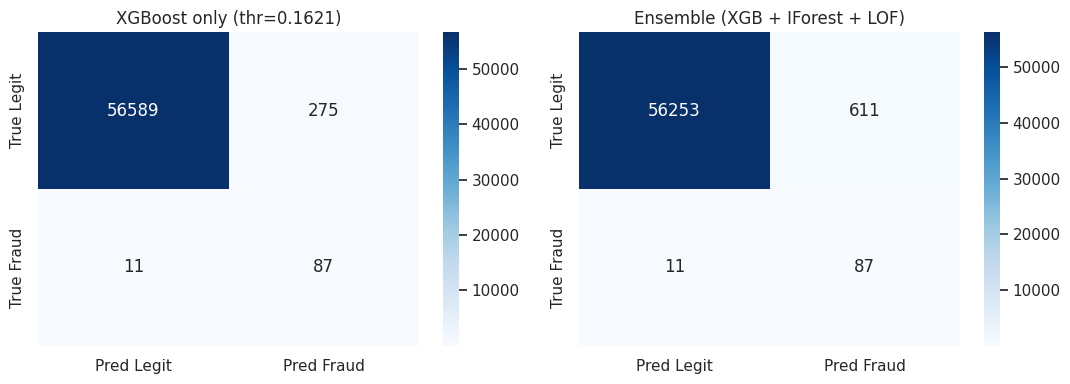

--- Post-ensemble fraud summary (test set) ---
  Total test frauds:        98
  Detected by ensemble:     87
  Remaining undetected:     11
  Cost of missed frauds:    8,347.09 AED
  Value of captured frauds: 127,677.22 AED
--- XGBoost vs Ensemble uplift ---
  XGBoost alone:  87 frauds caught, 275 false positives
  Ensemble:       87 frauds caught, 611 false positives
  Uplift:         +0 fraud(s) caught, +336 extra FP
  Precision ensemble (fraud class): 0.1246
  Recall    ensemble (fraud class): 0.8878


In [13]:
# ============================================================
# 10. Ensemble: XGBoost OR (IForest OR LOF)
#     Evaluation strictly on the test set
# ============================================================

# 10.1 — XGBoost flags
df_main["flag_xgb"] = (df_main["model_score"] >= best_thr)

# 10.2 — Unsupervised flags (only <50K legit-predicted)
ensemble_flags    = pd.Series(False, index=df_main.index)
mask_legit_lt_50k = mask_pred_legit_all & (df_main["Amount"] < 50000)
unsup_flags       = df_pred_legit["flag_iforest"] | df_pred_legit["flag_lof"]
ensemble_flags.loc[mask_legit_lt_50k] = unsup_flags.loc[mask_legit_lt_50k]

# 10.3 — Final ensemble flag
df_main["flag_ensemble"] = df_main["flag_xgb"] | ensemble_flags

# 10.4 — Evaluate on test set only
test_mask_main  = df_main.index.isin(idx_test)
y_true_test_ens = df_main.loc[test_mask_main, "Class"]
y_pred_test_ens = df_main.loc[test_mask_main, "flag_ensemble"]

cm_ens = confusion_matrix(y_true_test_ens, y_pred_test_ens)
print("--- Ensemble Confusion Matrix (test set) ---")
print(cm_ens)
tn_e, fp_e, fn_e, tp_e = cm_ens.ravel()
print(f"  TP (caught frauds): {tp_e}")
print(f"  FN (missed frauds): {fn_e}")
print(f"  FP (false alarms):  {fp_e}")
print(f"  TN (correct legit): {tn_e}")
print("--- Ensemble Classification Report ---")
print(classification_report(y_true_test_ens, y_pred_test_ens, digits=4))

# Side-by-side confusion matrix comparison
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cm, title in zip(
    axes,
    [cm_test, cm_ens],
    [f"XGBoost only (thr={best_thr:.4f})", "Ensemble (XGB + IForest + LOF)"]
):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred Legit", "Pred Fraud"],
                yticklabels=["True Legit", "True Fraud"], ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.savefig("cm_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# 10.5 — Remaining undetected frauds
df_test_ens      = df_main.loc[test_mask_main].copy()
remaining_frauds = df_test_ens[(df_test_ens["Class"] == 1) & (~df_test_ens["flag_ensemble"])]
recovered        = df_test_ens[df_test_ens["flag_ensemble"] & (df_test_ens["Class"] == 1)]

print(f"--- Post-ensemble fraud summary (test set) ---")
print(f"  Total test frauds:        {y_test.sum()}")
print(f"  Detected by ensemble:     {len(recovered)}")
print(f"  Remaining undetected:     {len(remaining_frauds)}")
print(f"  Cost of missed frauds:    {remaining_frauds['cost_if_fraud'].sum():,.2f} AED")
print(f"  Value of captured frauds: {recovered['cost_if_fraud'].sum():,.2f} AED")

# 10.6 — XGB vs Ensemble uplift
xgb_caught    = df_test_ens[df_test_ens["flag_xgb"] & (df_test_ens["Class"] == 1)]
uplift_frauds = len(recovered) - len(xgb_caught)
uplift_fp     = fp_e - fp_t

print(f"--- XGBoost vs Ensemble uplift ---")
print(f"  XGBoost alone:  {len(xgb_caught)} frauds caught, {fp_t} false positives")
print(f"  Ensemble:       {len(recovered)} frauds caught, {fp_e} false positives")
print(f"  Uplift:         +{uplift_frauds} fraud(s) caught, +{uplift_fp} extra FP")
print(f"  Precision ensemble (fraud class): {tp_e / (tp_e + fp_e):.4f}")
print(f"  Recall    ensemble (fraud class): {tp_e / (tp_e + fn_e):.4f}")
